# Simulations light inter

In [19]:
from __future__ import annotations

import os
import sys
from datetime import date

from scipy.interpolate import splev, splrep

sys.path.append("../data") 
from archi_dict import archi_sorghum as archi
# from oawidgets.plantgl import *  # noqa: F403

from openalea.archicrop.display import build_scene, display_scene  # noqa: F401
from openalea.archicrop.simulation import (
    compute_pot_growth,
    param_sampling,
)
from openalea.archicrop.viability import resolve_organ_growth
from openalea.plantgl.all import Color3, Material, Scene, Viewer  # noqa: F401

%gui qt

In [10]:
stics_color = "orange"
archicrop_color = "green"

In [11]:
seed = 18

In [13]:

n_samples = 6

param_sets = param_sampling(archi_params=archi, n_samples=n_samples, seed=seed, latin_hypercube=False)

daily_dynamics = {"Thermal time": range(0,1000,20)}

pot_la, pot_h, mtgs = compute_pot_growth(param_sets, daily_dynamics)


TypeError: range indices must be integers or slices, not str

In [ ]:
# ### Plot the 3D scene
# times = [t for i,t in enumerate(thermal_time) if i%10==0]
# mean_time = sum(times) / len(times)
# positions = [ (1*(t-mean_time), 0, 0) for t in times]
# nice_green = Color3((40, 80, 0))
# scene, _ = build_scene(
#     [g for i,g in enumerate(mtgs[id]) if i%10==0], 
#     position=positions, 
#     senescence=True, 
#     leaf_material = Material(nice_green), 
#     stem_material=Material(nice_green))
# display_scene(scene)

In [ ]:
from openalea.plantgl.all import Color3, Material, Scene, Viewer
from datetime import date

today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True)  # noqa: PTH103
# plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/plot_extin_coef_LAI_{parameter_name}.png")

nice_green = Color3((40, 80, 0))

for id,mtg in mtgs.items():
    Viewer.display(build_scene(mtg, senescence=True, leaf_material = Material(nice_green), stem_material=Material(nice_green))[0])
    Viewer.grids.setXYPlane(False)
    Viewer.grids.setYZPlane(False)
    Viewer.grids.setXZPlane(False)
    Viewer.camera.lookAt((386.117,-232.613,435.8), (0,0,100))
    Viewer.frameGL.saveImage(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/sorghum_{params_sets[id]['phyllochron']}_{params_sets[id]['rmax']}_{params_sets[id]['insertion_angle']}_{params_sets[id]['curvature']}.png")

In [ ]:
# g_direct = {id: mtg for id,mtg in mtgs.items()}
# g_direct[0].property("azimuth")

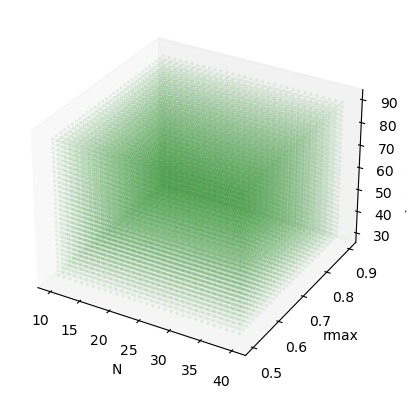

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(0.5, 0.9, len(p1))
p3 = np.linspace(30, 90, len(p1))

P1, P2, P3 = np.meshgrid(p1, p2, p3)

fig = plt.figure() # (constrained_layout=True, figsize=(8, 6))
# plt.subplots_adjust(left=0.1, right=0.85, bottom=0.1, top=0.9)
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='green', alpha=0.05)

ax.set_xlabel("N")
ax.set_ylabel("rmax")
ax.set_zlabel("insertion angle")
# ax.zaxis.set_label_coords(-0.1, 0.5)

ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_theoretical.png")
plt.show()


In [21]:
def compute_phi(nb_phy, end_veg, thermal_time, ligul_factor=1.6):
    phyllochron = (end_veg-thermal_time[0])/(nb_phy + ligul_factor)
    # for i,(N,phi) in enumerate(zip(range(nb_phy),phyllochron)):
    #     if min(p3) <= phi <= max(p3):
    #         np.delete(phyllochron, i)
    #         np.delete(nb_phy, i)
    return phyllochron

def compute_rmax(nb_phy, end_veg, index_end_veg, thermal_time, leaf_area_plant, ligul_factor=1.6, pot_factor=1.4):
    phyllochron = compute_phi(nb_phy, end_veg, thermal_time, ligul_factor)
    ligulochron = phyllochron * ligul_factor
    
    leaf_area_plant = leaf_area_plant[:index_end_veg+1]
    thermal_time = thermal_time[:index_end_veg+1]
    spl = splrep(thermal_time, leaf_area_plant)
    
    starts = []
    ends = []
    
    for i in range(nb_phy):
        start = i * phyllochron + thermal_time[0]
        end = start + ligulochron
        
        starts.append(round(start))
        ends.append(round(end))
    
    la_starts = splev(starts, spl)
    la_ends = splev(ends, spl)
    range_tt = range(round(thermal_time[0]), round(thermal_time[-1])+1)
    interp_la = splev(range_tt, spl)
    rates_la = [interp_la[i]-interp_la[i-1] if i > 0 else 0 for i in range(len(interp_la))]
    
    leaf_areas = resolve_organ_growth(nb_phy, ligul_factor, la_ends)
    
    S = []
    for t in range(max(ends)):
        sum_temp = 0
        for i,(s,e) in enumerate(zip(starts,ends)):
            if s <= t < e:
                sum_temp += (t-s)/(e-s) * leaf_areas[i]
            elif t >= e:
                sum_temp += leaf_areas[i]
        S.append(sum_temp)
       
    for i, la in enumerate(leaf_areas):
        if la == max(leaf_areas):
            id_max = i+1
            break
    
    rmax_int = np.arange(max(0,(id_max-1)/nb_phy), min(1,(id_max+1)/nb_phy), 0.02)
    
    # leaf_areas_norm = [la/max(leaf_areas) for la in leaf_areas]
    
    # skews_rmax = {}
    # id = 0
    # for rank in range(1, nb_phy+1):
    #     for rmax in rmax_int:
    #         if rmax != rank/nb_phy and leaf_areas[rank-1] > 0:
    #             skew = compute_skew(rank=rank, nb_phy=nb_phy, rmax=rmax, leaf_areas=leaf_areas_norm)
    #             if 1e-10 < skew < 1.0:
    #                 skews_rmax[id] = (skew, rmax)
    #                 id += 1
    
    # skew_int = []
    # for id,(skew,rmax) in skews_rmax.items():
    #     bell_shaped_leaf_areas = bell_shaped_dist(leaf_area_plant[-1]*pot_factor, nb_phy, rmax, skew)
    #     for i,bs in enumerate(bell_shaped_leaf_areas):
    #         if bs < leaf_areas[i]:
    #             break
    #         else:
    #             skew_int.append(skew)

    return id_max/nb_phy # rmax_int

In [22]:
from openalea.archicrop.stics_io import read_sti_file, get_stics_data

def stics_output(tec_file, plant_file, stics_output_file):
    """Extract relevant data from STICS output files."""

    density, daily_dynamics, lifespan, lifespan_early, inter_row = get_stics_data(
        file_tec_xml=tec_file,  # Path to the STICS management XML file
        file_plt_xml=plant_file,  # Path to the STICS plant XML file
        stics_output_file=stics_output_file  # Path to the STICS output file
    )

    thermal_time = [value["Thermal time"] for value in daily_dynamics.values()]
    leaf_area_plant = [value["Plant leaf area"] for value in daily_dynamics.values()]
    sen_leaf_area_plant = [value["Plant senescent leaf area"] for value in daily_dynamics.values()]
    height_canopy = [value["Plant height"] for value in daily_dynamics.values()]

    for key, value in daily_dynamics.items():
        if value["Phenology"] == 'juvenile':
            next_key = key + 1
            if next_key in daily_dynamics and daily_dynamics[next_key]["Phenology"] == 'exponential':
                end_juv = thermal_time[key-1] + thermal_time[0]

        elif value["Phenology"] == 'exponential':
            next_key = key + 1
            if next_key in daily_dynamics and daily_dynamics[next_key]["Phenology"] == 'repro':
                end_veg = thermal_time[key-1] + thermal_time[0]
                index_end_veg = key - 1
                break

    return density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg

tec_file='D:/ArchiCrop/data/02NT18SorgV2D1_tec.xml'
plant_file='D:/ArchiCrop/data/sorgho_imp_M_v10_plt.xml'
stics_output_file='D:/ArchiCrop/data/mod_s02NT18SorgV2D1.sti'
stics_output_file_pot='D:/ArchiCrop/data/mod_s02NT18SorgV2D1_no_stress.sti'

density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)
density_pot, daily_dynamics_pot, lifespan_pot, lifespan_early_pot, thermal_time_pot, leaf_area_plant_pot, sen_leaf_area_plant_pot, height_canopy_pot, end_juv_pot, end_veg_pot, index_end_veg_pot = stics_output(tec_file, plant_file, stics_output_file_pot)


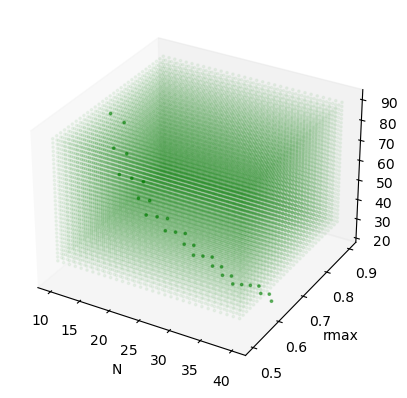

In [23]:
from scipy.spatial import ConvexHull

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(0.5, 0.9, len(p1))
p3 = np.linspace(30, 90, len(p1))

P1, P2, P3 = np.meshgrid(p1, p2, p3)

fig = plt.figure() 
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='green', alpha=0.05)

phi = compute_phi(p1, end_veg, thermal_time)
rmax = np.array([
    compute_rmax(n, end_veg, index_end_veg, thermal_time, leaf_area_plant)
    for n in p1
])

# P1_bis, P2_bis, P3_bis = np.meshgrid(p1, rmax, p3)

# phi = compute_phi(P1_bis, end_veg, thermal_time)

ax.scatter(
    p1, rmax, phi, s=3, c='green', alpha=0.5
)

ax.set_xlabel("N")
ax.set_ylabel("rmax")
ax.set_zlabel(r"$\phi$")

ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_stressed.png")
plt.show()


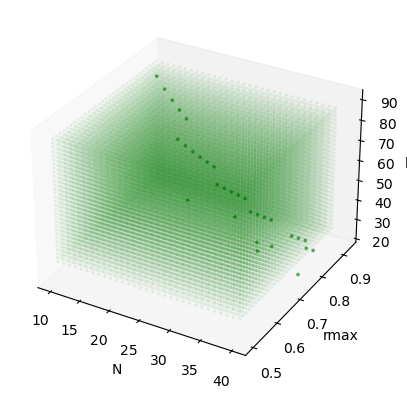

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(0.5, 0.9, len(p1))
p3 = np.linspace(30, 90, len(p1))

P1, P2, P3 = np.meshgrid(p1, p2, p3)

# p1_bis = np.arange(10, 20)
# p2_bis = np.linspace(0.6, 0.8, 20)
# p3_bis = np.linspace(10, 90, 20)

# P1_bis, P2_bis, P3_bis = np.meshgrid(p1_bis, p2_bis, p3_bis)

fig = plt.figure() # (constrained_layout=True, figsize=(8, 6))
# plt.subplots_adjust(left=0.1, right=0.85, bottom=0.1, top=0.9)
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='green', alpha=0.05)
# ax.scatter(P1_bis.ravel(), P2_bis.ravel(), P3_bis.ravel(), s=3, color='green', alpha=0.5)

phi = compute_phi(p1, end_veg_pot, thermal_time_pot)
rmax = np.array([
    compute_rmax(n, end_veg_pot, index_end_veg_pot, thermal_time_pot, leaf_area_plant_pot)
    for n in p1
])

# P1_bis, P2_bis, P3_bis = np.meshgrid(p1, rmax, p3)

# phi = compute_phi(P1_bis, end_veg_pot, thermal_time_pot)

ax.scatter(
    p1, rmax, phi, s=3, c='green', alpha=0.5
)

ax.set_xlabel("N")
ax.set_ylabel("rmax")
ax.set_zlabel("phi")
# ax.zaxis.set_label_coords(-0.1, 0.5)

ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_unstressed.png")
plt.show()


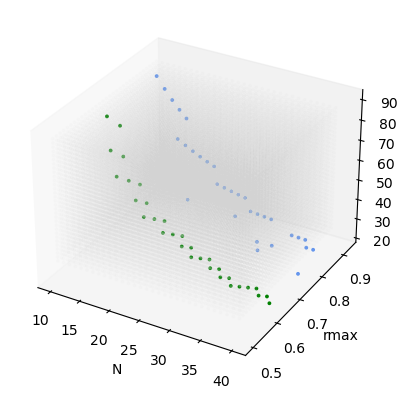

In [26]:
from scipy.spatial import ConvexHull
import numpy as np
import matplotlib.pyplot as plt

# Example parameter space
p1 = np.arange(10, 41)
p2 = np.linspace(0.5, 0.9, len(p1))
p3 = np.linspace(30, 90, len(p1))

P1, P2, P3 = np.meshgrid(p1, p2, p3)

fig = plt.figure() 
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='lightgrey', alpha=0.05)

phi = compute_phi(p1, end_veg_pot, thermal_time_pot)
rmax = np.array([
    compute_rmax(n, end_veg_pot, index_end_veg_pot, thermal_time_pot, leaf_area_plant_pot)
    for n in p1
])

ax.scatter(
    p1, rmax, phi, s=3, c='cornflowerblue', alpha=1
)


phi = compute_phi(p1, end_veg, thermal_time)
rmax = np.array([
    compute_rmax(n, end_veg, index_end_veg, thermal_time, leaf_area_plant)
    for n in p1
])

ax.scatter(
    p1, rmax, phi, s=3, c='green', alpha=1
)

ax.set_xlabel("N")
ax.set_ylabel("rmax")
ax.set_zlabel(r"$\phi$")

ax.grid(False)
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}", exist_ok=True) 
plt.savefig(f"D:/PhD_Oriane/simulations_ArchiCrop/{today_str}/morphospace_all.png")
plt.show()
